# Trying different class3 classification methods

The removal of nonevent can be done with very high accuracy (90%). It could be sensible to train a model to classify the different event types after that.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path


# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [195]:


data_dir = Path('../data')
output_dir = Path('../outputs')

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df_f = train_df
final_test_df = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date"])

In [196]:
train_df = train_df[train_df["class4"] != 'nonevent']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
X_train_f, y_train2_f, y_train4_f = ppm.split_xy(train_df_f)

In [197]:
y_train4.value_counts()

class4
II    117
Ib     82
Ia     26
Name: count, dtype: int64

## Scaling the data

In [198]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
scaler_f = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
#X_test_scaled = scaler.transform(X_test)

## Random forest classifier

In [199]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies = []
rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = rf_model.predict(X_test_fold)

    multiclass_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    multi_accuracies.append(multiclass_accuracy)

print(f"Average Accuracy: {np.mean(multi_accuracies):.4f}")

Average Accuracy: 0.5391


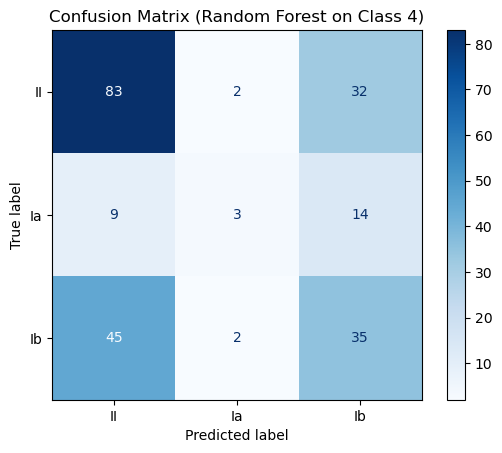

In [200]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(rf_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Random Forest on Class 4)")
plt.show()

## SVM with PCA

In [201]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies_svm = []
for n in range(1, 30):
    multi_accuracies_n = []
    #pca = PCA(n_components=n)
    svm = SVC(kernel='rbf')#, random_state=42)
    for train_index, test_index in skf.split(X_train_scaled, y_train4):
        '''
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train_scaled.index)
        X_train_fold, X_test_fold = X_train_pca.iloc[train_index], X_train_pca.iloc[test_index]
        y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        '''
        X_train_fold = X_train_scaled.iloc[train_index]
        X_test_fold  = X_train_scaled.iloc[test_index]
        y_train_fold = y_train4.iloc[train_index]
        y_test_fold  = y_train4.iloc[test_index]
        
        # Fit PCA on train fold only, transform both
        pca = PCA(n_components=n)
        #pca.fit_transform(X_train_f_scaled)  # Fit PCA on train fold
        X_train_pca = pca.fit_transform(X_train_fold)
        X_test_pca  = pca.transform(X_test_fold)

        #svm.fit(X_train_fold, y_train_fold.values.ravel())
        #accuracy = svm.score(X_test_fold, y_test_fold)
        svm.fit(X_train_pca, y_train_fold)
        accuracy = svm.score(X_test_pca, y_test_fold)
        multi_accuracies_n.append(accuracy)
    multi_accuracies_svm.append(np.mean(multi_accuracies_n))

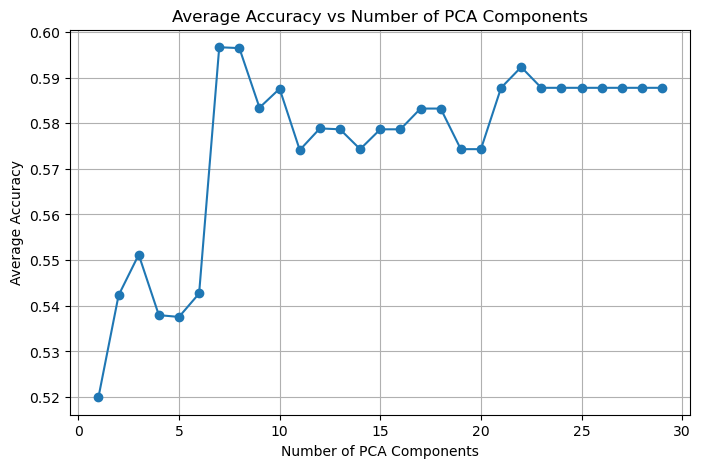

In [202]:
# Plotting the accuracy against number of PCA components
plt.figure(figsize=(8, 5))
plt.plot(range(1, 30), multi_accuracies_svm, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

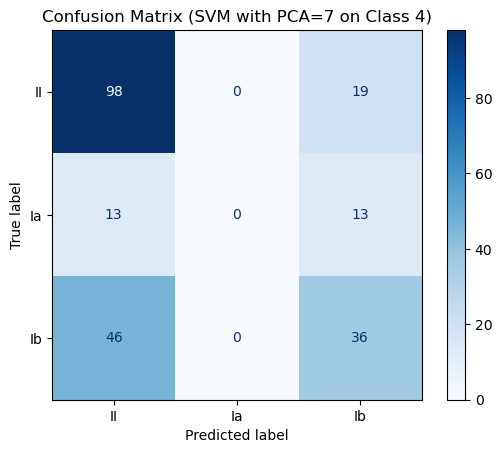

In [203]:
#Confusion matrix for best PCA component number
best_n = np.argmax(multi_accuracies_svm) + 1
svm = SVC(kernel='rbf')
all_preds = []
all_true = []
pca = PCA(n_components=best_n)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold = X_train_scaled.iloc[train_index]
    X_test_fold  = X_train_scaled.iloc[test_index]
    y_train_fold = y_train4.iloc[train_index]
    y_test_fold  = y_train4.iloc[test_index]
    
    # Fit PCA on train fold only, transform both
    pca.fit(X_train_fold)
    X_train_pca = pca.transform(X_train_fold)
    X_test_pca  = pca.transform(X_test_fold)

    svm.fit(X_train_pca, y_train_fold.values.ravel())
    all_preds.extend(svm.predict(X_test_pca))
    all_true.extend(y_test_fold)
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (SVM with PCA={best_n} on Class 4)")
plt.show()

## SVM PCA including testing set

This might perform better in the kaggle scoring. In theory PCA learns the test set structure.

In [204]:
X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final = scaler.transform(X_test_final)
#X_test_final = X_test_final.drop(columns=to_drop)


In [205]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies_svm = []
for n in range(1, 21):
    multi_accuracies_n = []
    svm = SVC(kernel='rbf')#, random_state=42)
    for train_index, test_index in skf.split(X_train_scaled, y_train4):
        '''
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train_scaled.index)
        X_train_fold, X_test_fold = X_train_pca.iloc[train_index], X_train_pca.iloc[test_index]
        y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        '''
        X_train_fold = X_train_scaled.iloc[train_index]
        X_train_pca_fold = pd.concat([X_train_fold, X_test_final], axis=0)
        assert list(X_train_fold.columns) == list(X_test_final.columns), "Column mismatch!"
        X_test_fold  = X_train_scaled.iloc[test_index]
        y_train_fold = y_train4.iloc[train_index]
        y_test_fold  = y_train4.iloc[test_index]
        # Fit PCA on train fold only, transform both
        pca = PCA(n_components=n)
        pca.fit(X_train_pca_fold)
        X_train_pca = pca.transform(X_train_fold)
        X_test_pca  = pca.transform(X_test_fold)

        #svm.fit(X_train_fold, y_train_fold.values.ravel())
        #accuracy = svm.score(X_test_fold, y_test_fold)
        svm.fit(X_train_pca, y_train_fold.values.ravel())
        accuracy = svm.score(X_test_pca, y_test_fold)
        multi_accuracies_n.append(accuracy)
    multi_accuracies_svm.append(np.mean(multi_accuracies_n))

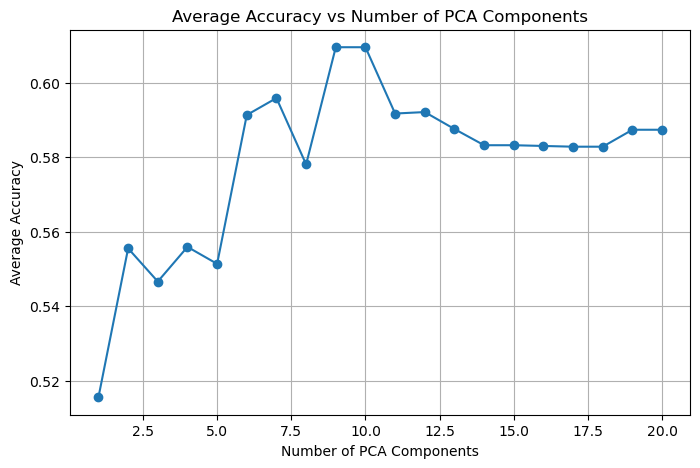

In [206]:
# Plotting the accuracy against number of PCA components
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), multi_accuracies_svm, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

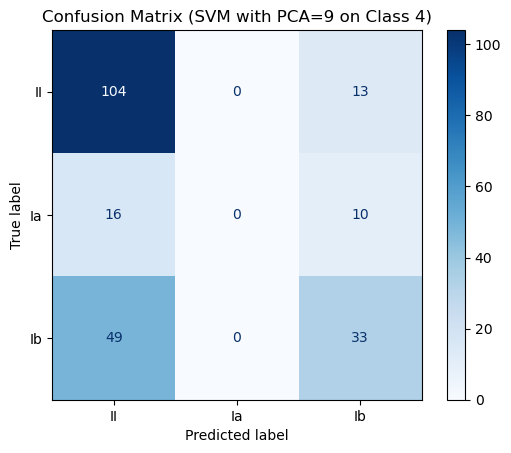

In [207]:
#confusion matrix for best PCA component number
best_n = np.argmax(multi_accuracies_svm) + 1
svm = SVC(kernel='rbf')
all_preds = []
all_true = []
pca = PCA(n_components=best_n)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold = X_train_scaled.iloc[train_index]
    X_train_pca_fold = pd.concat([X_train_fold, X_test_final], axis=0)
    assert list(X_train_fold.columns) == list(X_test_final.columns), "Column mismatch!"
    X_test_fold  = X_train_scaled.iloc[test_index]
    y_train_fold = y_train4.iloc[train_index]
    y_test_fold  = y_train4.iloc[test_index]
    
    # Fit PCA on train fold only, transform both
    pca.fit(X_train_pca_fold)
    X_train_pca = pca.transform(X_train_fold)
    X_test_pca  = pca.transform(X_test_fold)

    svm.fit(X_train_pca, y_train_fold.values.ravel())
    all_preds.extend(svm.predict(X_test_pca))
    all_true.extend(y_test_fold)
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (SVM with PCA={best_n} on Class 4)")
plt.show()

## Class Ia prevalence is very low. Trying logistic regression into Ib and II

In [208]:
#train_df_ev2 = train_df[train_df["class4"] != 'Ia']
#Map event Ia to Ib
train_df_ev2 = train_df.copy()
train_df_ev2['class4'] = train_df_ev2['class4'].replace({'Ia': 'II'})

X_train_ev2, _, y_train_ev2 = ppm.split_xy(train_df_ev2)

y_train_ev2.value_counts()

class4
II    143
Ib     82
Name: count, dtype: int64

In [209]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_ev2_scaled = scaler.fit_transform(X_train_ev2)
#X_test_scaled = scaler.transform(X_test)

In [210]:
#Fitting logistic regression to class2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss
    
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)


avg_accuracies = []
avg_perplexities = []

for c in np.linspace(0.1, 0.5, 50):
    accuracies = []
    perplexities = []
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    for train_index, test_index in skf.split(X_train_ev2_scaled, y_train_ev2):
        X_train_fold, X_test_fold = X_train_ev2_scaled.iloc[train_index], X_train_ev2_scaled.iloc[test_index]
        y_train_fold, y_test_fold = y_train_ev2.iloc[train_index], y_train_ev2.iloc[test_index]
        log_model.fit(X_train_fold, y_train_fold)
        y_pred_fold = log_model.predict(X_test_fold)
        y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

        binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
        perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
        accuracies.append(binary_accuracy)
        perplexities.append(perplexity)
    avg_accuracies.append(np.mean(accuracies))
    avg_perplexities.append(np.mean(perplexities))

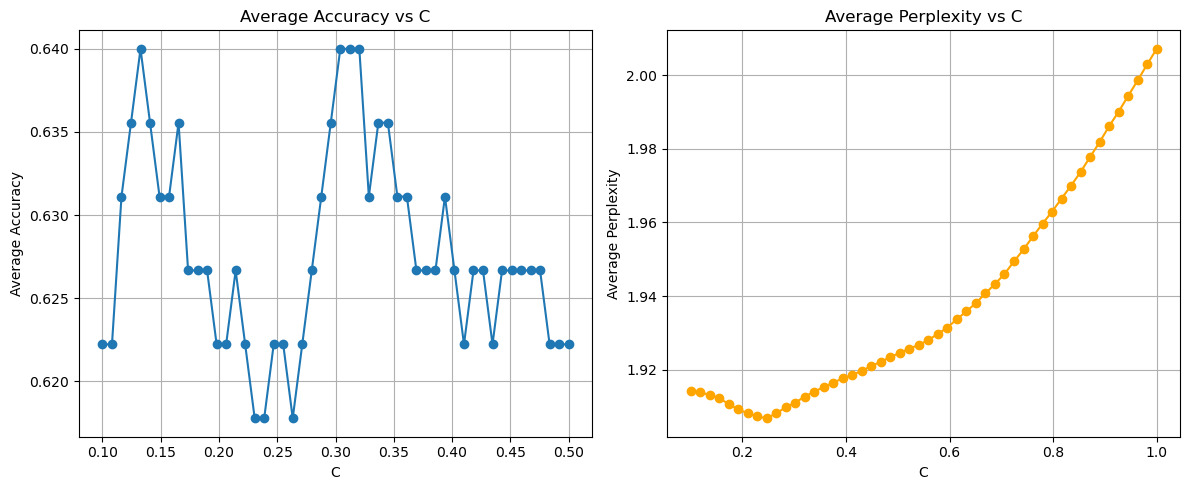

In [211]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.1, 0.5, 50), avg_accuracies, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.1, 1.0, 50), avg_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

In [212]:
# Trainig the best logistic regression model on the whole training set
best_c_index = np.argmax(avg_accuracies)
best_c = np.linspace(0.1, 0.5, 50)[best_c_index]
final_log_model = LogisticRegression(C=0.32, l1_ratio=1, solver='liblinear')

for train_index, test_index in skf.split(X_train_scaled, y_train4):
        X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
        y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        #Dropping IA from the training fold
        fold_train_df = pd.concat([X_train_fold, y_train_fold], axis=1)
        fold_train_df = fold_train_df[fold_train_df["class4"] != 'Ia']
        X_train_fold = fold_train_df.drop(columns=['class4'])
        y_train_fold = fold_train_df['class4']
        final_log_model.fit(X_train_fold, y_train_fold)
        
        y_pred_fold = final_log_model.predict(X_test_fold)
        y_pred_prob_fold = final_log_model.predict_proba(X_test_fold)[:, 1]

        binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
        #perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
        accuracies.append(binary_accuracy)
        #perplexities.append(perplexity)

print(f"Final Logistic Regression Model - Average Accuracy: {np.mean(accuracies):.4f}")

Final Logistic Regression Model - Average Accuracy: 0.6022
